# Laboratorio 5 — Clasificación de tweets usando minería de texto
### CC3084 Data Science — Semestre II, 2026 — Universidad del Valle de Guatemala
**Facultad de Ingeniería · Departamento de Ciencias de la Computación**

**Dataset:** *Natural Language Processing with Disaster Tweets* (Kaggle) — archivo `train.csv`.
**Objetivo:** clasificar si un tweet se refiere a un desastre real (`target = 1`) o no (`target = 0`).

---

**Requisitos**
```bash
pip install pandas numpy scipy scikit-learn matplotlib seaborn nltk wordcloud
```


---
# 0. Configuración e importación de módulos

Se documentan aquí todos los paquetes usados, tal como exige la rúbrica.

| Paquete | Uso en este laboratorio |
|---|---|
| `pandas`, `numpy` | Manipulación de datos y cálculo numérico |
| `re`, `html`, `string` (estándar) | Expresiones regulares, entidades HTML y puntuación en la limpieza |
| `matplotlib`, `seaborn` | Todas las figuras |
| `wordcloud` | Nubes de palabras (§4) |
| `nltk` | *Stopwords*, `WordNetLemmatizer`, léxico de opinión de Hu & Liu y VADER |
| `scikit-learn` | Vectorización TF-IDF, modelos, validación cruzada y métricas |
| `scipy.stats` | Prueba de Mann-Whitney U para comparar sentimiento entre categorías |


In [30]:
import re
import html
import string
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_auc_score,
                             RocCurveDisplay)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
TAB = Path("tablas"); TAB.mkdir(exist_ok=True)

def guardar(fig, nombre):
    """Guarda cada figura en figuras/ para poder referenciarla en el informe."""
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", dpi=150)
    return fig

print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

pandas 2.3.3 | numpy 2.2.6 | matplotlib 3.10.8


### 0.1 Recursos léxicos de NLTK

Se descargan cuatro recursos. Si no hay conexión, el notebook cae a alternativas embebidas para
seguir siendo reproducible:

- `stopwords` — artículos, preposiciones y conjunciones en inglés (ejercicio 3).
- `wordnet` / `omw-1.4` — lematización.
- `opinion_lexicon` — léxico de opinión de **Hu & Liu (2004)**: 2,006 palabras positivas y 4,783
  negativas. Es el que permite **contar** palabras positivas y negativas por tweet (ejercicio 8).
- `vader_lexicon` — **VADER** (Hutto & Gilbert, 2014), analizador de sentimiento diseñado
  específicamente para redes sociales: entiende emoticones, emojis, mayúsculas sostenidas,
  signos de exclamación e intensificadores.

In [31]:
USAR_NLTK = True
try:
    import nltk
    for recurso in ["stopwords", "wordnet", "omw-1.4", "opinion_lexicon", "vader_lexicon"]:
        try:
            nltk.download(recurso, quiet=True)
        except Exception:
            pass
    from nltk.corpus import stopwords as nltk_stopwords
    from nltk.stem import WordNetLemmatizer
    STOPWORDS_EN = set(nltk_stopwords.words("english"))
    _lem = WordNetLemmatizer(); _lem.lemmatize("running", "v")
    def lematizar(tok): return _lem.lemmatize(tok)
except Exception as e:
    USAR_NLTK = False
    print("NLTK no disponible, se usa respaldo embebido:", e)
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    STOPWORDS_EN = set(ENGLISH_STOP_WORDS)
    def lematizar(tok): return tok

# Decision documentada: NO se eliminan las negaciones. Cambian el sentido del tweet
# y son indispensables para el analisis de sentimiento del ejercicio 8.
NEGACIONES = {"no", "not", "nor", "never", "none", "nothing", "cannot", "can't",
              "don't", "doesn't", "didn't", "won't", "isn't", "aren't", "wasn't"}
STOPWORDS = (STOPWORDS_EN - NEGACIONES) | {"amp", "im", "rt", "u", "ur", "via", "http", "https", "co"}

print(f"NLTK activo: {USAR_NLTK} | stopwords usadas: {len(STOPWORDS)}")

NLTK activo: True | stopwords usadas: 197


---
# 1. Ejercicios 1 y 2 — Descarga y carga del conjunto de datos

`train.csv` proviene de la competencia de Kaggle *Natural Language Processing with Disaster Tweets*.

| Columna | Descripción |
|---|---|
| `id` | Identificador único del tweet |
| `keyword` | Palabra clave del tweet (puede venir vacía) |
| `location` | Ubicación declarada desde donde se envió el tweet (puede venir vacía) |
| `text` | Texto del tweet |
| `target` | 1 = desastre real, 0 = no desastre |


### 1.1 Carga del archivo

In [32]:
RUTA = Path("train.csv")
assert RUTA.exists(), "Coloque train.csv junto a este notebook (ejercicio 1)."

df = pd.read_csv(RUTA)
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [34]:
tabla1 = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
    "valores unicos": df.nunique(),
})
tabla1.to_csv(TAB / "tabla01_resumen_columnas.csv")
tabla1

,tipo,nulos,% nulos,valores unicos
id,int64,0,0.00,7613
keyword,object,61,0.80,221
location,object,2533,33.27,3341
text,object,0,0.00,7503
target,int64,0,0.00,2


### 1.2 Balance de la variable objetivo

target
0    4342
1    3271
Name: count, dtype: int64 

target
0    57.03
1    42.97
Name: proportion, dtype: float64


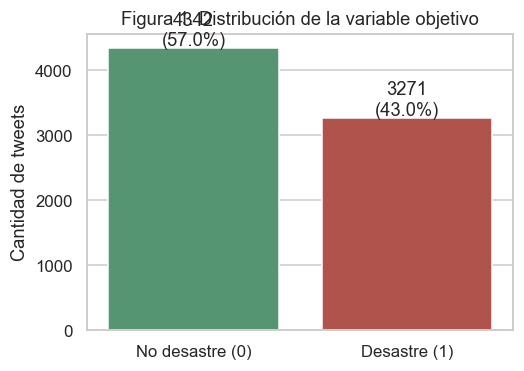

Baseline trivial (predecir siempre la clase mayoritaria): accuracy = 0.5703


In [35]:
conteo = df["target"].value_counts().sort_index()
prop = df["target"].value_counts(normalize=True).sort_index()
print(conteo, "\n"); print((prop * 100).round(2))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=["No desastre (0)", "Desastre (1)"], y=conteo.values, ax=ax,
            palette=["#4C9F70", "#C1443C"])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 30, f"{v}\n({prop.values[i]*100:.1f}%)", ha="center")
ax.set_title("Figura 1. Distribución de la variable objetivo")
ax.set_ylabel("Cantidad de tweets")
guardar(fig, "fig01_balance_target"); plt.show()

BASE_TRIVIAL = prop.max()
print(f"Baseline trivial (predecir siempre la clase mayoritaria): accuracy = {BASE_TRIVIAL:.4f}")

El desbalance es **leve** (≈57% / 43%), por lo que no se aplica sobremuestreo. Aun así se reportan
precisión, recall y F1 además de la exactitud, y todas las particiones son **estratificadas**. La línea
base trivial es el mínimo que cualquier modelo debe superar.

### 1.3 Duplicados y etiquetas inconsistentes

In [36]:
dups = df[df.duplicated("text", keep=False)]
print("Tweets con texto duplicado:", dups.shape[0])

inconsistentes = df.groupby("text")["target"].nunique().loc[lambda s: s > 1].index
print("Textos con etiqueta contradictoria:", len(inconsistentes))
df[df["text"].isin(inconsistentes)].sort_values("text").head(8)

Tweets con texto duplicado: 179
Textos con etiqueta contradictoria: 18


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it...,1
4244,6031,hazardous,"New Delhi, Delhi",#foodscare #offers2go #NestleIndia slips into ...,0
4221,5996,hazardous,NaN,#foodscare #offers2go #NestleIndia slips into ...,1
4239,6023,hazardous,"Mysore, Karnataka",#foodscare #offers2go #NestleIndia slips into ...,1
2832,4076,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,0
2831,4072,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1


Existen textos repetidos y, entre ellos, algunos etiquetados a la vez como 0 y como 1. Esto
refleja la ambigüedad real de la tarea (incluso anotadores humanos discrepan) e impone un techo al
desempeño máximo alcanzable.

---
# 2. Ejercicio 3 — Limpieza y preprocesamiento


### 2.1 Diagnóstico previo: ¿qué hay que limpiar?

Antes de decidir qué eliminar se cuantifican los artefactos presentes en el texto crudo. Este
diagnóstico es el que justifica cada decisión de la tabla de la sección 2.2, en particular la del
número `911` y la de los emoticones.

In [37]:
URL_RE     = re.compile(r"https?://\S+|www\.\S+")
MENCION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
NUM_RE     = re.compile(r"\b\d+\b")
EMOJI_RE   = re.compile("["
    "\U0001F300-\U0001F5FF" "\U0001F600-\U0001F64F" "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F" "\U0001F900-\U0001F9FF" "\U00002600-\U000027BF"
    "\U0001FA70-\U0001FAFF" "\U00002190-\U000021AA" "\U0000FE0F" "]+", flags=re.UNICODE)
# Emoticones ASCII clasicos, que VADER si sabe interpretar
EMOTICON_RE = re.compile(r"(?::|;|=)(?:-)?(?:\)|\(|D|P|/|\||O|o)")

d = df.copy()
d["n_caracteres"] = d["text"].str.len()
d["n_palabras"]   = d["text"].str.split().str.len()
d["n_urls"]       = d["text"].str.count(URL_RE)
d["n_menciones"]  = d["text"].str.count(MENCION_RE)
d["n_hashtags"]   = d["text"].str.count(HASHTAG_RE)
d["n_numeros"]    = d["text"].str.count(NUM_RE)
d["n_emojis"]     = d["text"].apply(lambda t: len(EMOJI_RE.findall(t)))
# Se quitan las URL antes de contar emoticones: "://" en un enlace haria match falso con ":/"
d["n_emoticones"] = d["text"].apply(lambda t: len(EMOTICON_RE.findall(URL_RE.sub(" ", t))))
d["tiene_911"]    = d["text"].str.contains(r"\b911\b", regex=True).astype(int)
d["prop_mayus"]   = d["text"].apply(lambda t: sum(c.isupper() for c in t) / max(len(t), 1))
d["n_exclam"]     = d["text"].str.count("!")

tabla2 = d.groupby("target")[["n_caracteres", "n_palabras", "n_urls", "n_menciones", "n_hashtags",
                              "n_numeros", "n_emojis", "n_emoticones", "tiene_911",
                              "prop_mayus", "n_exclam"]].mean().round(3)
tabla2.to_csv(TAB / "tabla02_artefactos_por_categoria.csv")
tabla2

,n_caracteres,n_palabras,n_urls,n_menciones,n_hashtags,n_numeros,n_emojis,n_emoticones,tiene_911,prop_mayus,n_exclam
target,,,,,,,,,,,
0,95.707,14.705,0.508,0.420,0.389,0.240,0.0,0.013,0.000,0.098,0.194
1,108.113,15.168,0.770,0.272,0.502,0.454,0.0,0.005,0.001,0.102,0.101


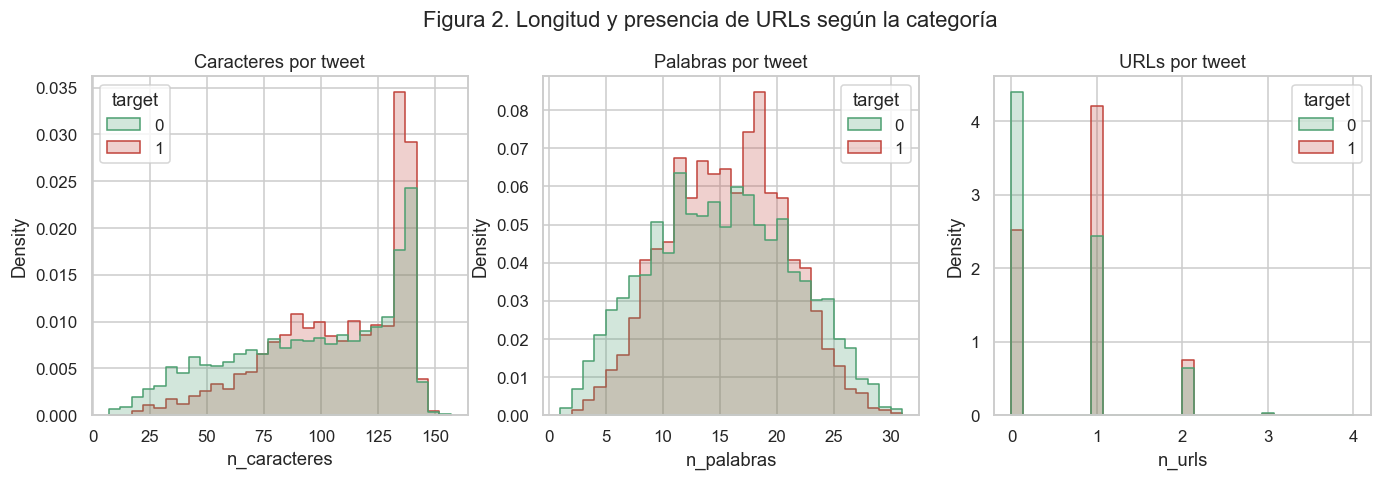

Tweets que contienen 911: 4
        sum    mean
target             
0         1  0.0002
1         3  0.0009

Tweets con al menos un emoji: 0 | con emoticón ASCII: 73


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo in zip(axes, ["n_caracteres", "n_palabras", "n_urls"],
                           ["Caracteres por tweet", "Palabras por tweet", "URLs por tweet"]):
    sns.histplot(data=d, x=col, hue="target", bins=30, element="step", stat="density",
                 common_norm=False, ax=ax, palette={0: "#4C9F70", 1: "#C1443C"})
    ax.set_title(titulo)
fig.suptitle("Figura 2. Longitud y presencia de URLs según la categoría", y=1.03)
guardar(fig, "fig02_artefactos"); plt.show()

print("Tweets que contienen 911:", d["tiene_911"].sum())
print(d.groupby("target")["tiene_911"].agg(["sum", "mean"]).round(4))
print("\nTweets con al menos un emoji:", (d["n_emojis"] > 0).sum(),
      "| con emoticón ASCII:", (d["n_emoticones"] > 0).sum())

**Lectura del diagnóstico (Tabla 2 y Figura 2):**

- Los tweets de desastre real son algo más largos y traen más URLs (enlazan notas de prensa);
  los no-desastre traen más menciones `@`, propias de conversación personal.
- `911` aparece en solo 4 tweets de 7,613 (3 en desastre real, 1 en no-desastre). Se evaluó si conservarlo, como pide el enunciado, y se conservó mapeándolo al token `num911`: el costo es nulo y el token es semánticamente relevante, pero con esa frecuencia no tiene impacto práctico en la clasificación. La conclusión es que la pregunta del enunciado se responde por el lado de la irrelevancia, no de la señal.
- El corpus no contiene ningún emoji (`n_emojis = 0`): todos llegaron corruptos como `\x89Û` por problemas de codificación en el scraping original. Sí hay 73 emoticones ASCII (`:)`, `:/`). Para el modelo se eliminan, pero se conservan el texto original y los conteos, porque en el ejercicio 8 sí se analizan.

### 2.2 Función de limpieza y justificación de cada paso

| # | Paso | Decisión | Justificación |
|---|---|---|---|
| 1 | Entidades HTML (`&amp;`) | Se decodifican con `html.unescape` | El scraping dejó entidades que ensucian los n-gramas |
| 2 | URLs | Se eliminan del texto; se guarda el conteo | La URL exacta no generaliza, pero su presencia sí es señal |
| 3 | Menciones `@usuario` | Se eliminan | Identifican cuentas, no el tema; provocan sobreajuste |
| 4 | Hashtags | Se quita el `#` y se conserva la palabra | `#earthquake` es contenido relevante |
| 5 | Emojis y emoticones | Se eliminan solo para el modelo; se cuentan aparte | Se analizan en el ejercicio 8 |
| 6 | Caracteres mal codificados | Se eliminan | Ruido de codificación sin significado |
| 7 | Minúsculas | Sí | Evita duplicar tokens (`Fire` / `fire`) |
| 8 | Números | Se eliminan excepto `911` → `num911` | Cifras sueltas no generalizan; `911` es indicador de emergencia |
| 9 | Puntuación y símbolos | Se eliminan | No aportan a un modelo bolsa-de-palabras |
| 10 | Stopwords | Se eliminan, conservando negaciones | `not`, `never` cambian el sentido |
| 11 | Tokens de un carácter | Se eliminan | Residuos de los pasos anteriores |
| 12 | Lematización | `WordNetLemmatizer` | Une fires/fire, killed/kill sin mutilar la palabra como un stemmer agresivo |


In [39]:
MOJIBAKE_RE = re.compile(r"[\x89\x9d\x8f\x9a\x93\x94\x97Û_ÓÏÊåÈ¨]|&#\d+;")

def limpiar_tweet(texto, conservar_911=True, quitar_stopwords=True, lematizar_tokens=True):
    """Pipeline de limpieza (ejercicio 3). Devuelve el texto normalizado listo para vectorizar."""
    t = str(texto)
    t = html.unescape(t)                       # 1
    t = URL_RE.sub(" ", t)                     # 2
    t = MENCION_RE.sub(" ", t)                 # 3
    t = HASHTAG_RE.sub(r"\1", t)               # 4
    t = EMOJI_RE.sub(" ", t)                   # 5
    t = MOJIBAKE_RE.sub(" ", t)                # 6
    t = t.lower()                              # 7
    if conservar_911:                          # 8
        t = re.sub(r"\b911\b", " num911 ", t)
    t = re.sub(r"\d+", " ", t)
    t = t.translate(str.maketrans("", "", string.punctuation))   # 9
    t = re.sub(r"[^a-z\s]", " ", t)
    tokens = t.split()
    if quitar_stopwords:                       # 10
        tokens = [w for w in tokens if w not in STOPWORDS]
    tokens = [w for w in tokens if len(w) > 1] # 11
    if lematizar_tokens:                       # 12
        tokens = [lematizar(w) for w in tokens]
    return " ".join(tokens)


def limpiar_para_sentimiento(texto):
    """Version ligera para el ejercicio 8: quita URLs, menciones y mojibake pero CONSERVA
    emojis, emoticones, puntuacion y mayusculas, porque VADER los usa como senal."""
    t = html.unescape(str(texto))
    t = URL_RE.sub(" ", t)
    t = MENCION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(r"\1", t)
    t = MOJIBAKE_RE.sub(" ", t)
    return re.sub(r"\s+", " ", t).strip()

ejemplo = df.loc[df["text"].str.contains("http", na=False), "text"].iloc[0]
print("ORIGINAL     :", ejemplo)
print("MODELO       :", limpiar_tweet(ejemplo))
print("SENTIMIENTO  :", limpiar_para_sentimiento(ejemplo))

ORIGINAL     : @bbcmtd Wholesale Markets ablaze http://t.co/lHYXEOHY6C
MODELO       : wholesale market ablaze
SENTIMIENTO  : Wholesale Markets ablaze


In [40]:
d["texto_limpio"] = d["text"].apply(limpiar_tweet)
d["texto_sent"]   = d["text"].apply(limpiar_para_sentimiento)
d["n_tokens"]     = d["texto_limpio"].str.split().str.len()

print("Tweets que quedaron vacios tras limpiar:", (d["n_tokens"] == 0).sum())
print("Promedio de tokens antes -> despues:",
      round(d["n_palabras"].mean(), 2), "->", round(d["n_tokens"].mean(), 2))
d[["text", "texto_limpio", "target"]].sample(5, random_state=RANDOM_STATE)

Tweets que quedaron vacios tras limpiar: 0
Promedio de tokens antes -> despues: 14.9 -> 8.65


,text,texto_limpio,target
2644,So you have a new weapon that can cause un-ima...,new weapon cause unimaginable destruction,1
2227,The f$&amp;@ing things I do for #GISHWHES Just...,thing gishwhes got soaked deluge going pad tam...,0
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,dt col police catch pickpocket liverpool stree,1
132,Aftershock back to school kick off was great. ...,aftershock back school kick great want thank e...,0
6845,in response to trauma Children of Addicts deve...,response trauma child addict develop defensive...,0


---
# 3. Ejercicio 4 — Frecuencias, n-gramas y probabilidades

Los n-gramas se generan con `CountVectorizer`, por separado para cada categoría. Para cada n-grama
se calcula:

- **Frecuencia absoluta** en cada clase.
- **Probabilidad relativa** $P(w \mid c) = \dfrac{count(w,c)}{\sum_{w'} count(w',c)}$, con suavizado
  de Laplace ($\alpha = 1$) para evitar probabilidades cero.
- **Log-odds** $\log \dfrac{P(w \mid c=1)}{P(w \mid c=0)}$, medida de poder discriminante.
- Para bigramas, la **probabilidad condicional** $P(w_2 \mid w_1)$, es decir el modelo de lenguaje
  bigrama de máxima verosimilitud (Jurafsky & Martin, cap. 3).

In [41]:
def tabla_ngramas(corpus_0, corpus_1, n, min_freq=3, alpha=1.0):
    """Frecuencias y probabilidades de n-gramas por clase, con log-odds (ejercicio 4)."""
    vec = CountVectorizer(ngram_range=(n, n), min_df=1)
    X = vec.fit_transform(list(corpus_0) + list(corpus_1))
    vocab = np.array(vec.get_feature_names_out())
    n0 = len(corpus_0)
    c0 = np.asarray(X[:n0].sum(axis=0)).ravel()
    c1 = np.asarray(X[n0:].sum(axis=0)).ravel()
    tot0, tot1, V = c0.sum(), c1.sum(), len(vocab)
    p0 = (c0 + alpha) / (tot0 + alpha * V)
    p1 = (c1 + alpha) / (tot1 + alpha * V)
    t = pd.DataFrame({"ngrama": vocab, "freq_no_desastre": c0, "freq_desastre": c1,
                      "P(w|no_desastre)": p0, "P(w|desastre)": p1})
    t["freq_total"] = t["freq_no_desastre"] + t["freq_desastre"]
    t["log_odds"] = np.log(t["P(w|desastre)"] / t["P(w|no_desastre)"])
    return (t[t["freq_total"] >= min_freq]
              .sort_values("freq_total", ascending=False).reset_index(drop=True))

corpus_0 = d.loc[d["target"] == 0, "texto_limpio"]
corpus_1 = d.loc[d["target"] == 1, "texto_limpio"]

uni = tabla_ngramas(corpus_0, corpus_1, 1)
bi  = tabla_ngramas(corpus_0, corpus_1, 2)
tri = tabla_ngramas(corpus_0, corpus_1, 3, min_freq=2)

for nombre, t in [("unigramas", uni), ("bigramas", bi), ("trigramas", tri)]:
    t.to_csv(TAB / f"tabla03_ngramas_{nombre}.csv", index=False)
    print(f"{nombre}: {len(t)} n-gramas por encima del umbral de frecuencia")

unigramas: 3874 n-gramas por encima del umbral de frecuencia
bigramas: 2323 n-gramas por encima del umbral de frecuencia
trigramas: 3406 n-gramas por encima del umbral de frecuencia


### 3.1 Palabras más frecuentes en cada categoría

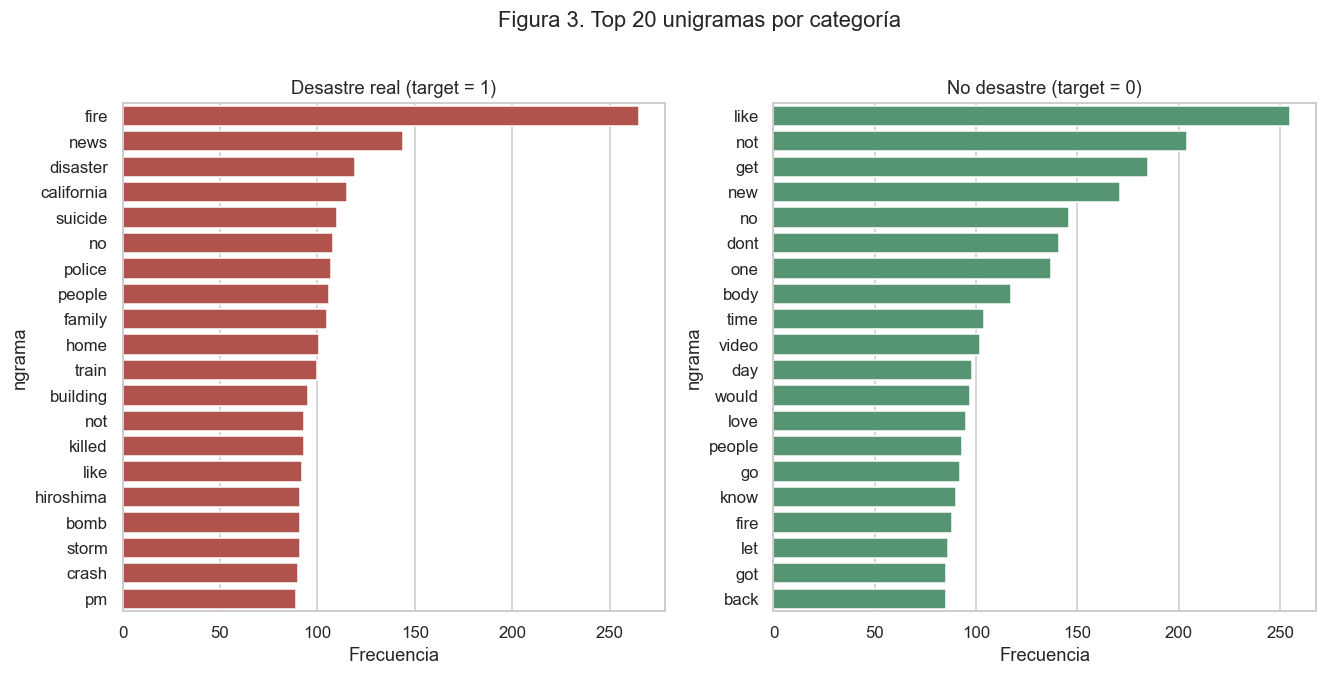

Palabra mas repetida en DESASTRE   : fire -> 265
Palabra mas repetida en NO DESASTRE: like -> 255


In [42]:
top0 = uni.sort_values("freq_no_desastre", ascending=False).head(20)
top1 = uni.sort_values("freq_desastre", ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=top1["freq_desastre"], y=top1["ngrama"], ax=axes[0], color="#C1443C")
axes[0].set_title("Desastre real (target = 1)"); axes[0].set_xlabel("Frecuencia")
sns.barplot(x=top0["freq_no_desastre"], y=top0["ngrama"], ax=axes[1], color="#4C9F70")
axes[1].set_title("No desastre (target = 0)"); axes[1].set_xlabel("Frecuencia")
fig.suptitle("Figura 3. Top 20 unigramas por categoría", y=1.02)
guardar(fig, "fig03_top_unigramas"); plt.show()

print("Palabra mas repetida en DESASTRE   :", top1.iloc[0]["ngrama"], "->", int(top1.iloc[0]["freq_desastre"]))
print("Palabra mas repetida en NO DESASTRE:", top0.iloc[0]["ngrama"], "->", int(top0.iloc[0]["freq_no_desastre"]))

### 3.2 ¿Qué palabras servirán para un mejor modelo? (log-odds)

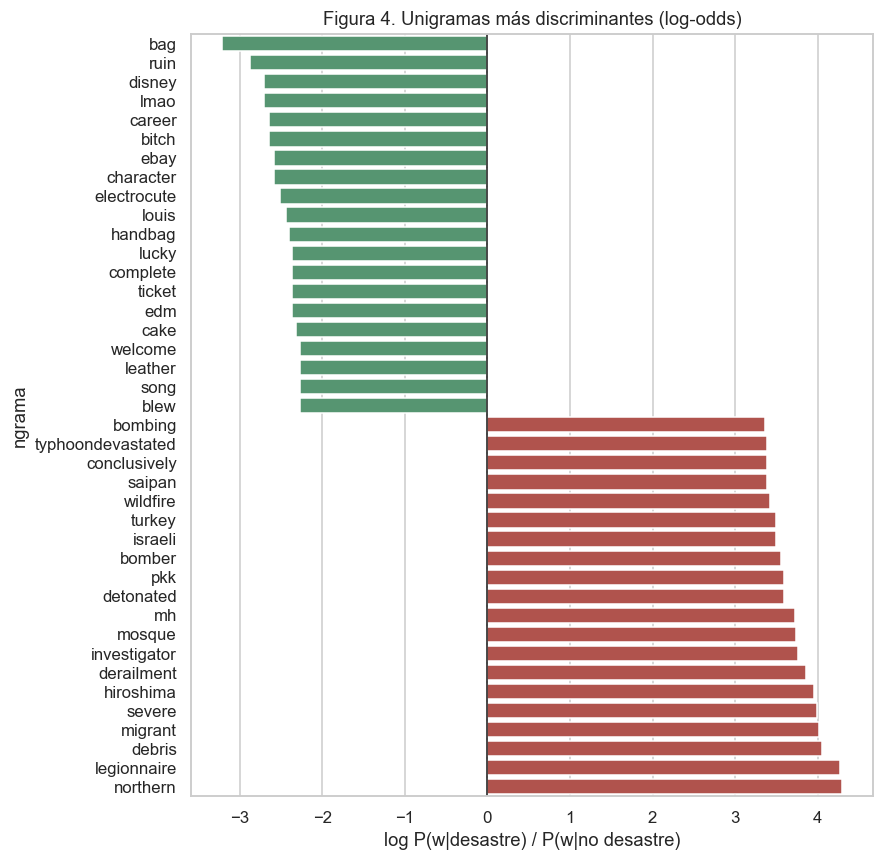

,ngrama,freq_desastre,freq_no_desastre,log_odds
111,northern,64,0,4.298119
114,legionnaire,62,0,4.266866
179,debris,50,0,4.055557
185,migrant,48,0,4.015552
194,severe,47,0,3.994933
61,hiroshima,91,1,3.952373
267,derailment,41,0,3.861401
335,investigator,37,0,3.761318
352,mosque,36,0,3.734649
84,mh,72,1,3.721044


In [43]:
disc = uni[uni["freq_total"] >= 10].copy()
mas_desastre = disc.nlargest(20, "log_odds")
mas_normal   = disc.nsmallest(20, "log_odds")

sel = pd.concat([mas_desastre, mas_normal]).sort_values("log_odds")
fig, ax = plt.subplots(figsize=(8, 9))
sns.barplot(x=sel["log_odds"], y=sel["ngrama"], ax=ax,
            palette=["#4C9F70" if v < 0 else "#C1443C" for v in sel["log_odds"]])
ax.axvline(0, c="k", lw=1)
ax.set_title("Figura 4. Unigramas más discriminantes (log-odds)")
ax.set_xlabel("log P(w|desastre) / P(w|no desastre)")
guardar(fig, "fig04_logodds"); plt.show()

mas_desastre[["ngrama", "freq_desastre", "freq_no_desastre", "log_odds"]].head(15)

**Respuesta:** las palabras útiles no son las más frecuentes sino las de **log-odds extremo**. Los
términos con log-odds alto son vocabulario técnico de emergencia y los de log-odds bajo son
vocabulario coloquial. Las palabras de log-odds ≈ 0 (§4.4) no aportan y solo agregan dimensionalidad.

### 3.3 ¿Vale la pena explorar bigramas y trigramas?

In [44]:
bi_disc  = bi[bi["freq_total"] >= 5].nlargest(15, "log_odds")
tri_disc = tri[tri["freq_total"] >= 3].nlargest(15, "log_odds")
print("BIGRAMAS mas asociados a desastre real:")
display(bi_disc[["ngrama", "freq_desastre", "freq_no_desastre", "log_odds"]])
print("TRIGRAMAS mas asociados a desastre real:")
display(tri_disc[["ngrama", "freq_desastre", "freq_no_desastre", "log_odds"]])

BIGRAMAS mas asociados a desastre real:


,ngrama,freq_desastre,freq_no_desastre,log_odds
0,suicide bomber,60,0,4.174762
5,northern california,41,0,3.801558
8,california wildfire,36,0,3.674806
9,suicide bombing,34,0,3.619236
14,bomber detonated,30,0,3.497875
18,home razed,29,0,3.465085
20,confirmed mh,29,0,3.465085
22,pkk suicide,28,0,3.431184
24,razed northern,28,0,3.431184
25,latest home,28,0,3.431184


TRIGRAMAS mas asociados a desastre real:


,ngrama,freq_desastre,freq_no_desastre,log_odds
0,suicide bomber detonated,30,0,3.488492
1,northern california wildfire,29,0,3.455702
2,home razed northern,28,0,3.421801
3,latest home razed,28,0,3.421801
4,pkk suicide bomber,28,0,3.421801
5,bomber detonated bomb,28,0,3.421801
6,razed northern california,27,0,3.386709
7,yr old pkk,27,0,3.386709
8,old pkk suicide,27,0,3.386709
9,family sue legionnaire,26,0,3.350342


In [45]:
# Evidencia cuantitativa: el unigrama "fire" es ambiguo, los bigramas lo desambiguan
def desglose(termino, n):
    t = {1: uni, 2: bi, 3: tri}[n]
    return t[t["ngrama"].str.contains(rf"\b{termino}\b", regex=True)] \
             .nlargest(8, "freq_total")[["ngrama", "freq_desastre", "freq_no_desastre", "log_odds"]]

print("Unigrama 'fire':"); display(desglose("fire", 1))
print("Bigramas que contienen 'fire':"); display(desglose("fire", 2))

Unigrama 'fire':


,ngrama,freq_desastre,freq_no_desastre,log_odds
0,fire,265,88,1.218591


Bigramas que contienen 'fire':


,ngrama,freq_desastre,freq_no_desastre,log_odds
21,forest fire,20,8,0.911186
31,wild fire,25,2,2.223372
108,fire truck,10,9,0.159198
110,bush fire,17,2,1.855648
236,building fire,12,1,1.935690
387,rocky fire,9,0,2.366473
397,fire alarm,7,2,1.044717
484,fire caught,7,0,2.143330


**Respuesta:** sí, los bigramas valen la pena. El unigrama `fire` aparece en ambas clases porque
cubre tanto el incendio literal como el uso figurado (*this album is fire*). Al pasar a bigramas el
contexto local desambigua: combinaciones como *forest fire* o *wild fire* se concentran en la clase de
desastre, mientras que *on fire* en sentido figurado no. Por eso la vectorización del modelo usa
`ngram_range=(1,2)`.

**Los trigramas no se incluyen en el modelo:** aportan poca información adicional sobre los bigramas,
tienen frecuencias muy bajas (casi todos aparecen 2 o 3 veces) y disparan la dimensionalidad, lo que
favorece el sobreajuste. Se calculan y documentan, pero se descartan como característica.

### 3.4 Probabilidad condicional bigrama P(w₂|w₁)

In [46]:
def probabilidades_condicionales(corpus, top=15):
    """P(w2|w1) = count(w1,w2)/count(w1), estimacion de maxima verosimilitud."""
    unigramas, bigramas = Counter(), Counter()
    for doc in corpus:
        toks = doc.split()
        unigramas.update(toks); bigramas.update(zip(toks, toks[1:]))
    return pd.DataFrame([{"w1": w1, "w2": w2, "count(w1,w2)": c,
                          "count(w1)": unigramas[w1], "P(w2|w1)": c / unigramas[w1]}
                         for (w1, w2), c in bigramas.most_common(top)])

print("Bigramas mas probables — DESASTRE REAL"); display(probabilidades_condicionales(corpus_1))
print("Bigramas mas probables — NO DESASTRE");   display(probabilidades_condicionales(corpus_0))

Bigramas mas probables — DESASTRE REAL


,w1,w2,"count(w1,w2)",count(w1),P(w2|w1)
0,suicide,bomber,60,110,0.545455
1,northern,california,41,64,0.640625
2,oil,spill,38,44,0.863636
3,california,wildfire,36,115,0.313043
4,burning,building,36,64,0.562500
5,suicide,bombing,34,110,0.309091
6,bomber,detonated,30,61,0.491803
7,confirmed,mh,29,45,0.644444
8,yr,old,29,37,0.783784
9,home,razed,29,101,0.287129


Bigramas mas probables — NO DESASTRE


,w1,w2,"count(w1,w2)",count(w1),P(w2|w1)
0,body,bag,48,117,0.410256
1,cross,body,38,44,0.863636
2,liked,video,34,37,0.918919
3,look,like,32,71,0.450704
4,full,read,28,82,0.341463
5,feel,like,25,55,0.454545
6,body,bagging,23,117,0.196581
7,burning,building,23,56,0.410714
8,reddit,quarantine,21,38,0.552632
9,quarantine,offensive,21,29,0.724138


---
# 4. Ejercicio 5 — Análisis exploratorio

### 4.1 Cruce de `keyword` con `target`

Nulos en keyword: 61 (0.80%) | keywords distintas: 221


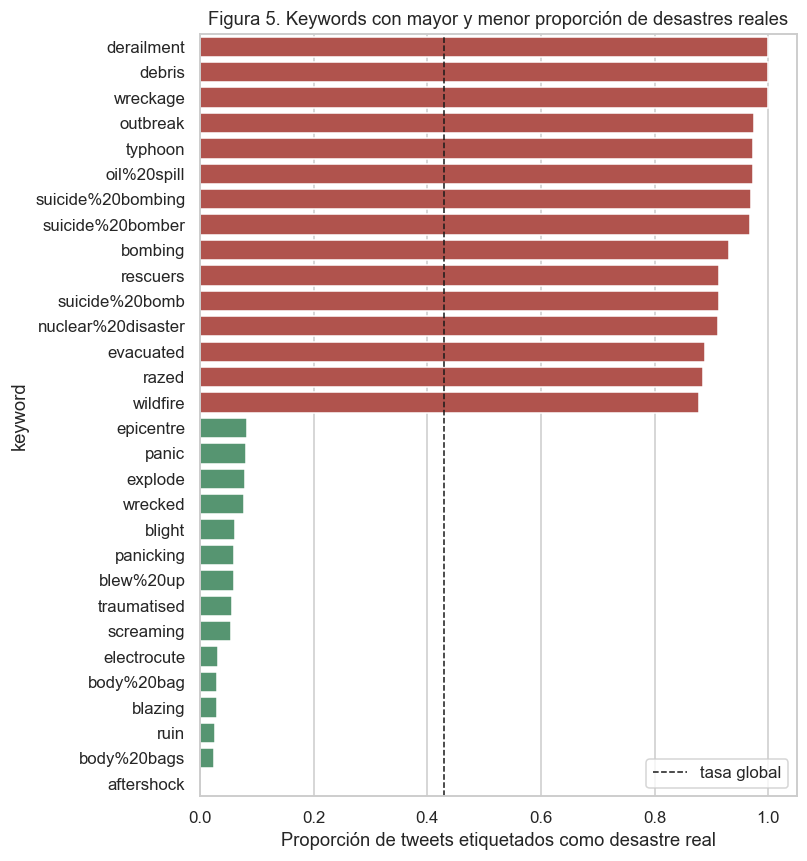

,n,tasa_desastre
keyword,,
derailment,39,1.000000
debris,37,1.000000
wreckage,39,1.000000
outbreak,40,0.975000
typhoon,38,0.973684
oil%20spill,38,0.973684
suicide%20bombing,33,0.969697
suicide%20bomber,31,0.967742
bombing,29,0.931034


In [47]:
print("Nulos en keyword:", df["keyword"].isna().sum(),
      f"({df['keyword'].isna().mean()*100:.2f}%) | keywords distintas:", df["keyword"].nunique())

kw = (df.dropna(subset=["keyword"]).groupby("keyword")
        .agg(n=("target", "size"), tasa_desastre=("target", "mean"))
        .sort_values("tasa_desastre", ascending=False))
kw.to_csv(TAB / "tabla04_keyword_tasa_desastre.csv")

top_kw = pd.concat([kw.head(15), kw.tail(15)])
fig, ax = plt.subplots(figsize=(7, 9))
sns.barplot(x=top_kw["tasa_desastre"], y=top_kw.index, ax=ax,
            palette=["#C1443C"]*15 + ["#4C9F70"]*15)
ax.axvline(df["target"].mean(), ls="--", c="k", lw=1, label="tasa global")
ax.set_title("Figura 5. Keywords con mayor y menor proporción de desastres reales")
ax.set_xlabel("Proporción de tweets etiquetados como desastre real"); ax.legend()
guardar(fig, "fig05_keyword_tasa"); plt.show()
kw.head(10)

`keyword` es muy informativa por sí sola: hay palabras clave con tasa de desastre cercana a 1 y
otras cercana a 0, donde el término se usa casi siempre en sentido figurado. Por eso en (5) se
concatena `keyword` al texto como entrada del modelo.

### 4.2 Variable `location`

In [48]:
print("Nulos en location:", df["location"].isna().sum(),
      f"({df['location'].isna().mean()*100:.2f}%) | ubicaciones distintas:", df["location"].nunique())
print(df["location"].value_counts().head(15))

loc = (df.dropna(subset=["location"]).groupby("location")
         .agg(n=("target", "size"), tasa_desastre=("target", "mean"))
         .query("n >= 15").sort_values("n", ascending=False).head(15))
loc

Nulos en location: 2533 (33.27%) | ubicaciones distintas: 3341
location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Washington, DC      21
Kenya               20
Worldwide           19
Australia           18
Chicago, IL         18
Name: count, dtype: int64


,n,tasa_desastre
location,,
USA,104,0.644231
New York,71,0.225352
United States,50,0.540000
London,45,0.355556
Canada,29,0.448276
Nigeria,28,0.785714
UK,27,0.592593
"Los Angeles, CA",26,0.307692
India,24,0.833333


`location` es un campo de texto libre sin normalizar: conviven países, ciudades, estados y
entradas que no son lugares reales. Con ~33% de faltantes y cardinalidad altísima, se descarta como
predictor y se conserva solo con fines descriptivos.

### 4.3 Nubes de palabras

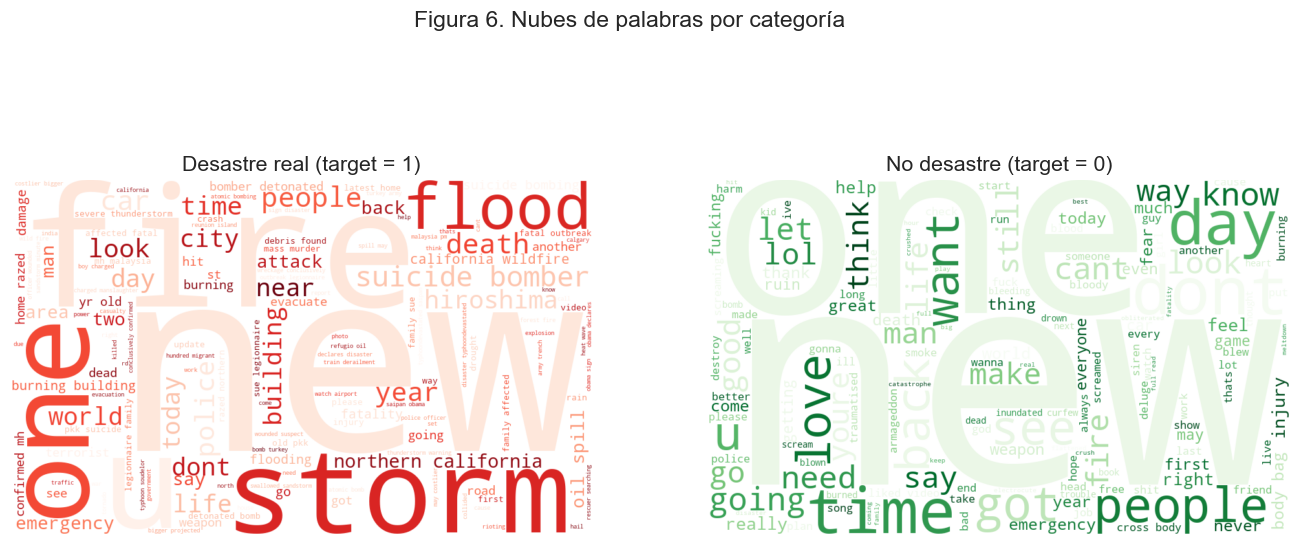

In [49]:
try:
    from wordcloud import WordCloud
    wc_ok = True
except ImportError:
    wc_ok = False
    print("Instale wordcloud:  pip install wordcloud")

if wc_ok:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, corpus, titulo, cmap in [
            (axes[0], corpus_1, "Desastre real (target = 1)", "Reds"),
            (axes[1], corpus_0, "No desastre (target = 0)", "Greens")]:
        wc = WordCloud(width=900, height=550, background_color="white", colormap=cmap,
                       max_words=150, random_state=RANDOM_STATE).generate(" ".join(corpus))
        ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(titulo, fontsize=14)
    fig.suptitle("Figura 6. Nubes de palabras por categoría", y=1.02, fontsize=15)
    guardar(fig, "fig06_nubes_por_categoria"); plt.show()

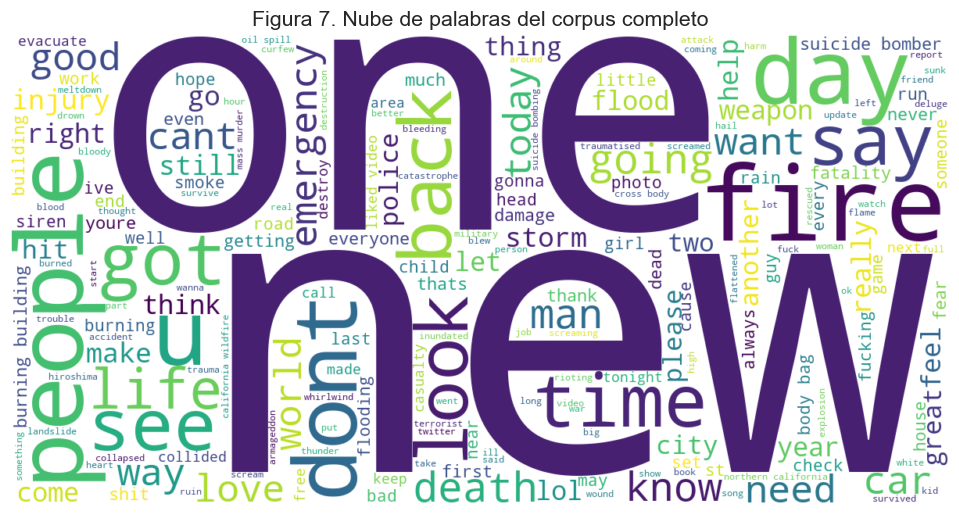

In [50]:
if wc_ok:
    fig, ax = plt.subplots(figsize=(11, 6))
    wc = WordCloud(width=1200, height=600, background_color="white", colormap="viridis",
                   max_words=200, random_state=RANDOM_STATE).generate(" ".join(d["texto_limpio"]))
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title("Figura 7. Nube de palabras del corpus completo", fontsize=14)
    guardar(fig, "fig07_nube_global"); plt.show()

### 4.4 Histograma de las palabras más repetidas y palabras presentes en ambas categorías

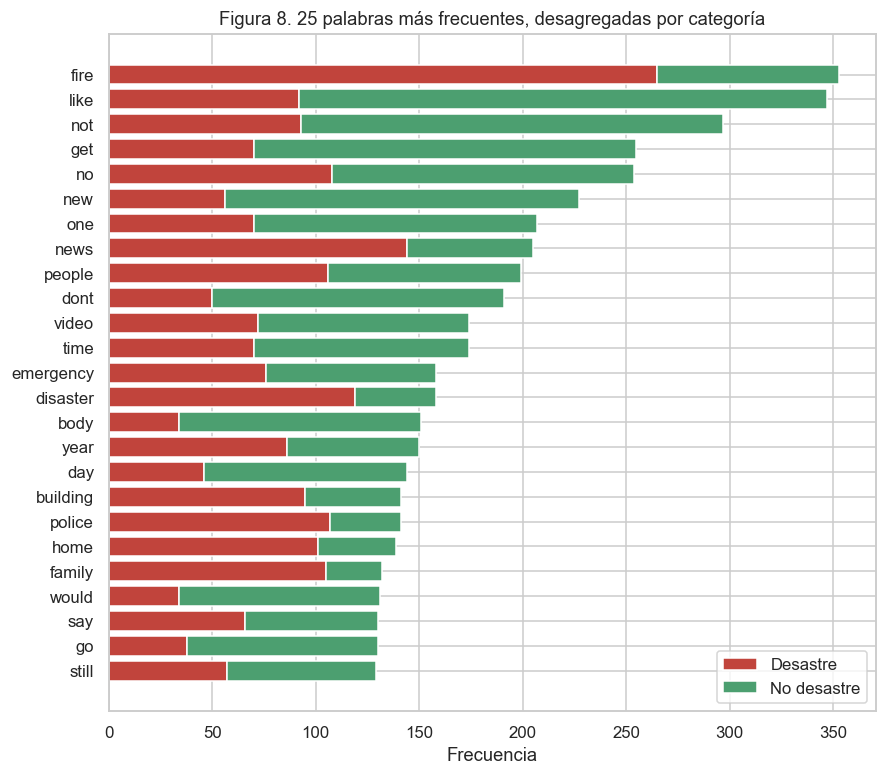

In [51]:
top_global = uni.nlargest(25, "freq_total").sort_values("freq_total")
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_global["ngrama"], top_global["freq_desastre"], color="#C1443C", label="Desastre")
ax.barh(top_global["ngrama"], top_global["freq_no_desastre"],
        left=top_global["freq_desastre"], color="#4C9F70", label="No desastre")
ax.set_title("Figura 8. 25 palabras más frecuentes, desagregadas por categoría")
ax.set_xlabel("Frecuencia"); ax.legend()
guardar(fig, "fig08_histograma_palabras"); plt.show()

In [52]:
ambas = uni[(uni["freq_desastre"] >= 15) & (uni["freq_no_desastre"] >= 15)].copy()
neutrales = ambas.reindex(ambas["log_odds"].abs().sort_values().index).head(20)
neutrales[["ngrama", "freq_desastre", "freq_no_desastre", "log_odds"]]

,ngrama,freq_desastre,freq_no_desastre,log_odds
25,life,59,67,-0.001432
75,could,38,43,0.003104
430,hijacking,15,17,0.005948
233,china,20,23,-0.009800
392,chemical,16,18,0.012506
97,another,32,37,-0.017347
297,ok,18,20,0.023648
79,plan,35,41,-0.030419
362,bombed,16,19,-0.038787
94,school,32,38,-0.043323


**Discusión sobre las palabras presentes en todas las categorías.** 
Los términos con log-odds cercano a cero aparecen con frecuencia relativa casi idéntica en ambas clases: son vocabulario
general de Twitter y no aportan poder discriminante, solo dimensionalidad y riesgo de ruido.
Hay tres formas de tratarlas y aquí se usan las dos primeras: (i) las que además son *stopwords*
ya se eliminaron en (2); (ii) TF-IDF penaliza automáticamente las de alta frecuencia documental
al bajar su peso, razón de peso para preferirlo sobre conteos crudos; (iii) podrían eliminarse a
mano con una lista negra, opción que se descarta porque TF-IDF ya lo resuelve sin perder información.

---
# 5. Ejercicio 6 — Modelos de clasificación


### 5.1 ¿Cómo se aborda el contexto?

Un modelo bolsa-de-palabras pierde el orden de las palabras y con él el contexto. Se ataca en cuatro niveles, de menor a mayor costo. Los tres primeros están implementados en este avance; el cuarto queda para la entrega final:

1. **N-gramas (1,2)** en la vectorización: los bigramas recuperan contexto local y desambiguan los
   usos figurados detectados en 3.3.
2. **TF-IDF** en lugar de conteos crudos: baja el peso de los términos ubicuos de 4.4.
3. **`keyword` concatenada al texto**: aporta el contexto temático que el propio dataset ya trae
   anotado y que la Figura 5 mostró altamente predictivo.
4. **Variable de sentimiento** *(ejercicio 10, entrega final)*: un rasgo semántico que no depende del vocabulario exacto y ayudaría justamente en los casos figurados.

Queda documentada una quinta ruta, fuera del alcance de este laboratorio: *embeddings* contextuales
tipo BERT, que modelan el orden completo de la oración y son el estado del arte en esta competencia.

### 5.2 Protocolo experimental

Partición estratificada 80/20 con semilla fija; selección por validación cruzada estratificada de 5
pliegues **sobre el conjunto de entrenamiento**; el conjunto de prueba se reserva intacto hasta la
evaluación final.

In [53]:
d["keyword_limpia"] = (d["keyword"].fillna("").str.replace("%20", " ", regex=False)
                          .apply(lambda k: limpiar_tweet(k) if k else ""))
d["entrada"] = (d["texto_limpio"] + " " + d["keyword_limpia"]).str.strip()

X = d["entrada"]; y = d["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
idx_train, idx_test = X_train.index, X_test.index

print(f"Entrenamiento: {len(X_train)} tweets | Prueba: {len(X_test)} tweets")
print("Proporcion de desastres — train:", round(y_train.mean(), 4),
      "| test:", round(y_test.mean(), 4))

Entrenamiento: 6090 tweets | Prueba: 1523 tweets
Proporcion de desastres — train: 0.4297 | test: 0.4294


### 5.3 Modelos evaluados y sus parámetros

| Modelo | Parámetros | Razón de inclusión |
|---|---|---|
| Naive Bayes multinomial | `alpha=0.5` | Línea base clásica en texto; asume independencia entre términos |
| Regresión logística | `C=5.0`, `max_iter=2000` | Coeficientes interpretables; fuerte en alta dimensión dispersa |
| SVM lineal | `LinearSVC(C=0.5)` calibrado con `CalibratedClassifierCV` | Suele ser el mejor en texto disperso; se calibra para obtener probabilidades |
| Random Forest | `n_estimators=400`, `min_samples_leaf=2` | Contraste no lineal; captura interacciones entre términos |

Vectorización común: `TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9, sublinear_tf=True)`.

In [54]:
def vectorizador():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9,
                           sublinear_tf=True, strip_accents="unicode")

def construir_modelos():
    return {
        "Naive Bayes multinomial": MultinomialNB(alpha=0.5),
        "Regresion logistica":     LogisticRegression(C=5.0, max_iter=2000,
                                                      random_state=RANDOM_STATE),
        "SVM lineal":              CalibratedClassifierCV(
                                       LinearSVC(C=0.5, random_state=RANDOM_STATE), cv=3),
        "Random Forest":           RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                                          n_jobs=-1, random_state=RANDOM_STATE),
    }

def evaluar(pipe, Xtr, ytr, Xte, yte, nombre, cv=None):
    """Entrena, valida de forma cruzada y evalua en prueba. Devuelve la fila de metricas."""
    fila = {"modelo": nombre}
    if cv is not None:
        f1_cv = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="f1", n_jobs=-1)
        fila["F1 (CV 5-fold)"] = round(f1_cv.mean(), 4)
        fila["sd CV"] = round(f1_cv.std(), 4)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte); proba = pipe.predict_proba(Xte)[:, 1]
    p, r, f1, _ = precision_recall_fscore_support(yte, pred, average="binary")
    fila.update({"Accuracy (test)": round(accuracy_score(yte, pred), 4),
                 "Precision (test)": round(p, 4), "Recall (test)": round(r, 4),
                 "F1 (test)": round(f1, 4), "ROC-AUC (test)": round(roc_auc_score(yte, proba), 4)})
    return fila, pipe

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados, entrenados = [], {}
for nombre, clf in construir_modelos().items():
    pipe = Pipeline([("tfidf", vectorizador()), ("clf", clf)])
    fila, pipe = evaluar(pipe, X_train, y_train, X_test, y_test, nombre, cv)
    resultados.append(fila); entrenados[nombre] = pipe

tabla5 = pd.DataFrame(resultados).sort_values("F1 (test)", ascending=False)
tabla5.to_csv(TAB / "tabla05_comparacion_modelos.csv", index=False)
tabla5

,modelo,F1 (CV 5-fold),sd CV,Accuracy (test),Precision (test),Recall (test),F1 (test),ROC-AUC (test)
2,SVM lineal,0.7434,0.0081,0.8194,0.8174,0.7462,0.7802,0.8707
1,Regresion logistica,0.7412,0.0074,0.8175,0.8133,0.7462,0.7783,0.8676
0,Naive Bayes multinomial,0.7391,0.0059,0.8201,0.8571,0.6972,0.7690,0.8711
3,Random Forest,0.7327,0.0163,0.8089,0.8081,0.7278,0.7659,0.8607


In [55]:
mejor_nombre = tabla5.iloc[0]["modelo"]
mejor = entrenados[mejor_nombre]
F1_BASE = tabla5.iloc[0]["F1 (test)"]
print("Mejor modelo (ejercicio 6):", mejor_nombre)
print(f"Supera la linea base trivial de accuracy {BASE_TRIVIAL:.4f}\n")
print(classification_report(y_test, mejor.predict(X_test),
                            target_names=["No desastre", "Desastre real"]))

Mejor modelo (ejercicio 6): SVM lineal
Supera la linea base trivial de accuracy 0.5703

               precision    recall  f1-score   support

  No desastre       0.82      0.87      0.85       869
Desastre real       0.82      0.75      0.78       654

     accuracy                           0.82      1523
    macro avg       0.82      0.81      0.81      1523
 weighted avg       0.82      0.82      0.82      1523



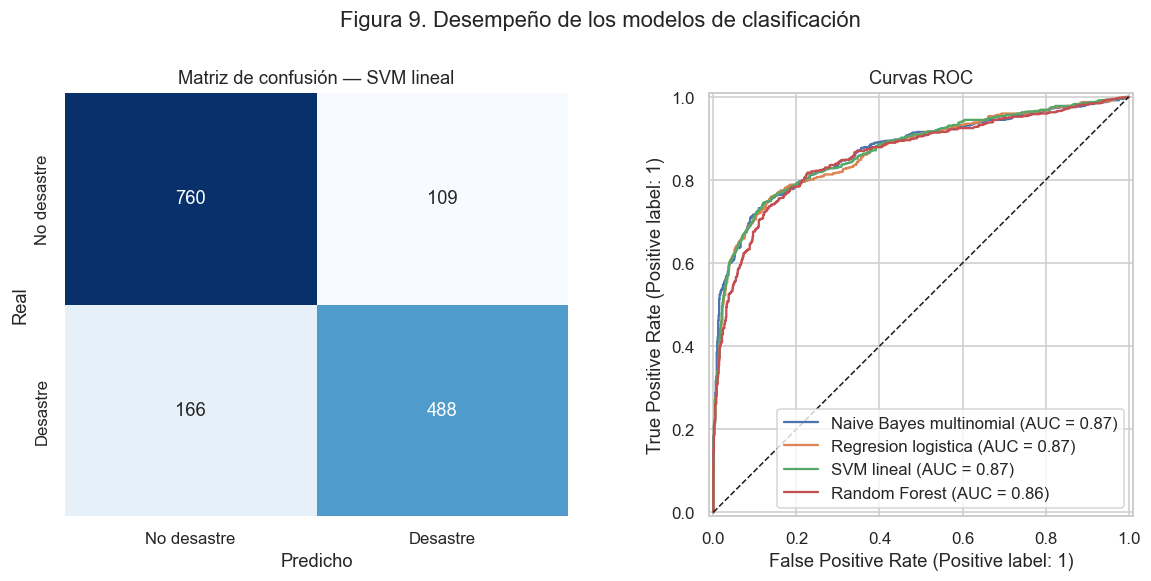

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, mejor.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["No desastre", "Desastre"], yticklabels=["No desastre", "Desastre"])
axes[0].set_title(f"Matriz de confusión — {mejor_nombre}")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")
for nombre, pipe in entrenados.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=nombre)
axes[1].plot([0, 1], [0, 1], "k--", lw=1); axes[1].set_title("Curvas ROC")
fig.suptitle("Figura 9. Desempeño de los modelos de clasificación", y=1.03)
guardar(fig, "fig09_desempeno_modelos"); plt.show()

### 5.4 ¿Qué aprendió el modelo? Verificación de sanidad

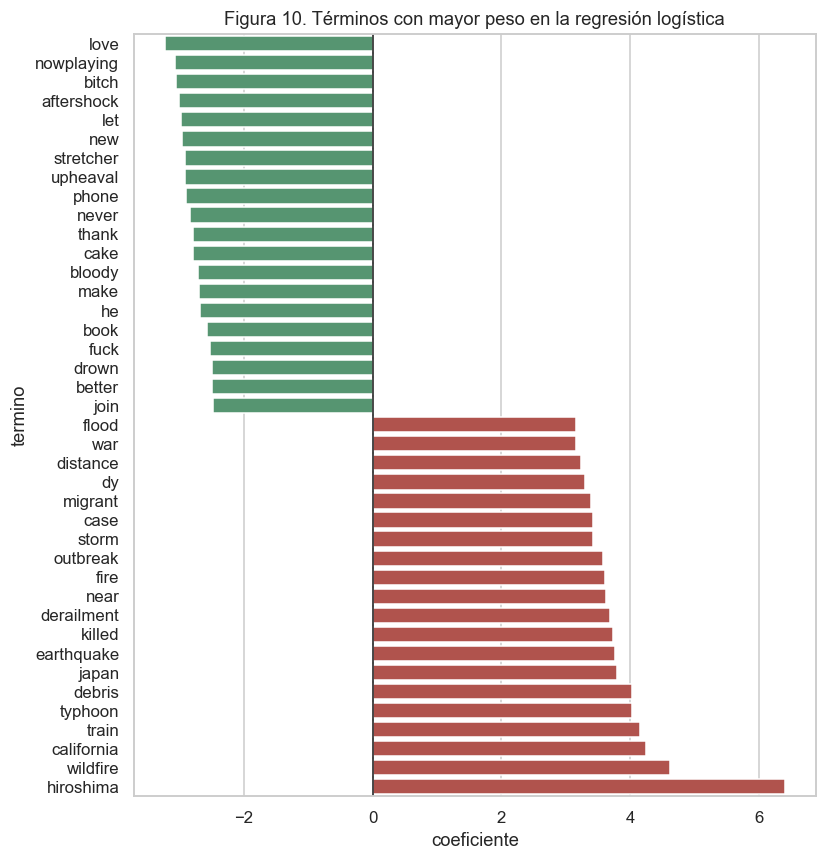

In [57]:
pipe_lr = entrenados["Regresion logistica"]
nombres = np.array(pipe_lr.named_steps["tfidf"].get_feature_names_out())
coefs = pipe_lr.named_steps["clf"].coef_[0]
idx_pos, idx_neg = np.argsort(coefs)[-20:], np.argsort(coefs)[:20]
pesos = pd.DataFrame({"termino": np.concatenate([nombres[idx_neg], nombres[idx_pos]]),
                      "coeficiente": np.concatenate([coefs[idx_neg], coefs[idx_pos]])}
                    ).sort_values("coeficiente")
fig, ax = plt.subplots(figsize=(8, 9))
sns.barplot(x=pesos["coeficiente"], y=pesos["termino"], ax=ax,
            palette=["#4C9F70" if v < 0 else "#C1443C" for v in pesos["coeficiente"]])
ax.axvline(0, c="k", lw=1)
ax.set_title("Figura 10. Términos con mayor peso en la regresión logística")
guardar(fig, "fig10_coeficientes"); plt.show()

Los términos de mayor peso coinciden con los de log-odds extremo de la Figura 4, lo que confirma que el modelo aprendió señal real y no artefactos del preprocesamiento.

### 5.5 Análisis de errores

In [58]:
pred = mejor.predict(X_test)
err = d.loc[idx_test].assign(pred=pred).query("target != pred")
print(f"Errores: {len(err)} de {len(X_test)} ({len(err)/len(X_test)*100:.2f}%)")
print("\nFALSOS POSITIVOS (no era desastre, se predijo desastre):")
display(err.query("target == 0")[["text", "keyword"]].head(5))
print("FALSOS NEGATIVOS (era desastre, se predijo no desastre):")
display(err.query("target == 1")[["text", "keyword"]].head(5))

Errores: 275 de 1523 (18.06%)

FALSOS POSITIVOS (no era desastre, se predijo desastre):


,text,keyword
4863,@TheEconomist Step one: get that mass murderer...,mass%20murderer
1358,if firefighters acted like cops they'd drive a...,burning%20buildings
2685,Ignition Knock (Detonation) Sensor-Senso Stand...,detonation
244,@POTUS Maybe we should call Israel and tell th...,annihilation
5267,@TroySlaby22 slicker than an oil spill,oil%20spill


FALSOS NEGATIVOS (era desastre, se predijo no desastre):


,text,keyword
6837,Hollywood Movie About Trapped Miners Released ...,trapped
6167,Thu Aug 06 2015 01:20:32 GMT+0000 (UTC)\n#mill...,sirens
2905,I can't drown my demons they know how to swim,drown
1956,@XHNews We need these plants in the pacific du...,cyclone
6818,Bomb head? Explosive decisions dat produced mo...,trapped


**Patrón de los errores:** los falsos positivos son en su mayoría usos figurados o hiperbólicos del vocabulario de catástrofe; los falsos negativos, tweets de desastre real sin vocabulario explícito, que dependen de conocimiento del mundo o del contenido del enlace. Ambos casos apuntan a
la misma limitación (el contexto) y motivan la variable de sentimiento del ejercicio 10, que se desarrolla en la entrega final.

---
### Referencias

- Jurafsky, D., & Martin, J. H. *Speech and Language Processing* (3.ª ed.). Capítulo de N-gramas. https://web.stanford.edu/~jurafsky/slp3/
- Feinerer, I., Hornik, K., & Meyer, D. (2008). Text Mining Infrastructure in R. *Journal of Statistical Software*, 25(5), 1–54.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media (NLTK).
- Kaggle. *Natural Language Processing with Disaster Tweets*. https://www.kaggle.com/competitions/nlp-getting-started
